### Imports

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

from bayesian_gpr import Atom, Scene, render_atoms
from bayesian_gpr.forward import render_atom
from bayesian_gpr.viz import plot_bscan

### Load scene and define model

In [12]:
# ---------------------------------------------------------------------
# Scene and posterior settings
# ---------------------------------------------------------------------

DATA_PATH = Path("data/scene.npz")

SIGMA = 0.02
LAMBDA_R = 10.0
DEFAULT_EPS_R = 1.0

scene = Scene.load(DATA_PATH)

X_MAX = scene.grid.x_extent
D_MAX = scene.grid.t_max * scene.soil.v / 2.0

PARAMETER_NAMES = ("x0", "depth", "R", "amplitude")

print("Scene path:", DATA_PATH.resolve())
print(f"x0 support:        [0, {X_MAX:.6g}]")
print(f"depth support:     [0, {D_MAX:.6g}]")
print("radius support:    [0, infinity)")
print("amplitude support: [-1, 1]")

Scene path: /Users/stellasrzich/Documents/University of Otago/MSc in Physics/Basin MCMC/Basin-MCMC/data/scene.npz
x0 support:        [0, 50]
depth support:     [0, 1.99862]
radius support:    [0, infinity)
amplitude support: [-1, 1]


### Define the representative atom and generate synthetic data

In [14]:
representative_atom = Atom(
    x0=25.0,
    depth=1.5,
    R=0.10,
    amplitude=0.8,
    eps_r=DEFAULT_EPS_R,
)

# Noise-free synthetic observed data.
data = np.asarray(
    render_atom(
        representative_atom,
        scene.grid,
        scene.wavelet,
        scene.soil,
    ),
    dtype=float,
)

print("Representative atom:")
print(
    np.array(
        [
            representative_atom.x0,
            representative_atom.depth,
            representative_atom.R,
            representative_atom.amplitude,
        ]
    )
)

print("\nSynthetic data shape:", data.shape)
print("Synthetic data minimum:", data.min())
print("Synthetic data maximum:", data.max())
print("Synthetic data L2 norm:", np.linalg.norm(data))

Representative atom:
[25.   1.5  0.1  0.8]

Synthetic data shape: (2000, 5000)
Synthetic data minimum: -0.11648365746630937
Synthetic data maximum: 0.2609784717376828
Synthetic data L2 norm: 22.57610160567584


### Plot the synthetic data

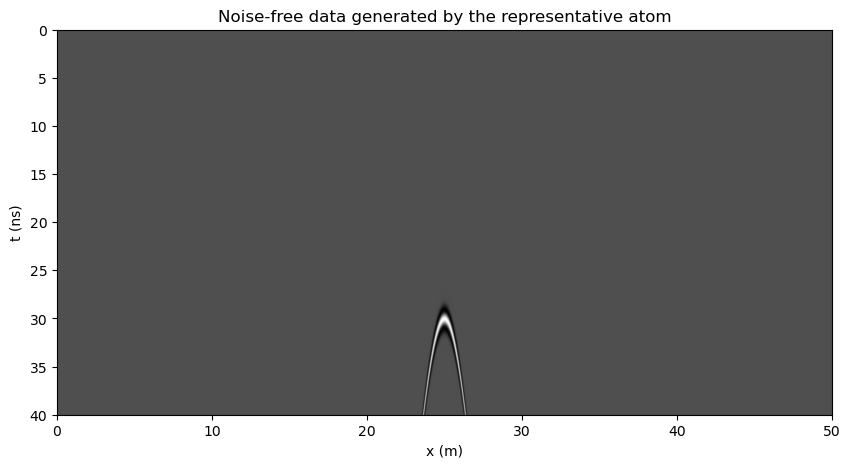

In [15]:
figure, axis = plt.subplots(figsize=(10, 5))

plot_bscan(
    data,
    scene.grid,
    ax=axis,
)

axis.set_title("Noise-free data generated by the representative atom")
plt.show()

### Conversion and rendering helper functions

In [16]:
def atom_to_vector(atom: Atom) -> np.ndarray:
    """Convert one Atom to [x0, depth, R, amplitude]."""
    return np.array(
        [atom.x0, atom.depth, atom.R, atom.amplitude],
        dtype=float,
    )


def vector_to_atom(theta: np.ndarray) -> Atom:
    """Convert [x0, depth, R, amplitude] to one Atom."""
    theta = np.asarray(theta, dtype=float)

    if theta.shape != (4,):
        raise ValueError("theta must have shape (4,)")

    return Atom(
        x0=float(theta[0]),
        depth=float(theta[1]),
        R=float(theta[2]),
        amplitude=float(theta[3]),
        eps_r=DEFAULT_EPS_R,
    )


def render_one_atom(theta: np.ndarray) -> np.ndarray:
    """Render one atom represented by a four-component vector."""
    atom = vector_to_atom(theta)

    return np.asarray(
        render_atom(
            atom,
            scene.grid,
            scene.wavelet,
            scene.soil,
        ),
        dtype=float,
    )


def render_two_atoms(theta: np.ndarray) -> np.ndarray:
    """Render a two-atom state with shape (2, 4)."""
    theta = np.asarray(theta, dtype=float)

    if theta.shape != (2, 4):
        raise ValueError("theta must have shape (2, 4)")

    return render_one_atom(theta[0]) + render_one_atom(theta[1])

### Log prior, likelihood, and posterior

In [17]:
def valid_atom(theta: np.ndarray) -> bool:
    """Return whether one atom lies in the prior support."""
    x0, depth, radius, amplitude = theta

    return (
        np.all(np.isfinite(theta))
        and 0.0 <= x0 <= X_MAX
        and 0.0 <= depth <= D_MAX
        and radius >= 0.0
        and -1.0 <= amplitude <= 1.0
    )


def valid_state(theta: np.ndarray) -> bool:
    """Return whether both atoms lie in the prior support."""
    theta = np.asarray(theta, dtype=float)
    return theta.shape == (2, 4) and all(valid_atom(atom) for atom in theta)


def log_prior(theta: np.ndarray) -> float:
    """Log prior for a state conditional on there being exactly two atoms."""
    if not valid_state(theta):
        return -math.inf

    # The x0, depth, and amplitude priors are uniform.
    # Their density constants do not affect MH acceptance probabilities.
    #
    # Each radius independently has an Exponential(LAMBDA_R) prior.
    return -LAMBDA_R * np.sum(theta[:, 2])


def log_likelihood_from_render(rendered: np.ndarray) -> float:
    """Gaussian log likelihood, up to a state-independent constant."""
    residual = rendered - data
    return -0.5 * np.sum(residual * residual) / SIGMA**2


def log_posterior(theta: np.ndarray) -> float:
    """Unnormalised log posterior on the fixed n=2 subspace."""
    prior = log_prior(theta)

    if not math.isfinite(prior):
        return -math.inf

    rendered = render_two_atoms(theta)
    return prior + log_likelihood_from_render(rendered)

### Initialise the two atoms

In [18]:
representative_vector = atom_to_vector(representative_atom)

initial_state = np.vstack(
    [
        representative_vector.copy(),
        representative_vector.copy(),
    ]
)

initial_state[:, 3] = representative_atom.amplitude / 2.0

print("Initial two-atom state:")
print(initial_state)

initial_render = render_two_atoms(initial_state)

print("\nInitial residual L2 norm:")
print(np.linalg.norm(initial_render - data))

print("\nInitial log posterior:")
print(log_posterior(initial_state))

Initial two-atom state:
[[25.   1.5  0.1  0.4]
 [25.   1.5  0.1  0.4]]

Initial residual L2 norm:
0.0

Initial log posterior:
-2.0


### Component-wise random-walk MH sampler

In [19]:
def run_two_atom_mh(
    initial_state: np.ndarray,
    *,
    warmup: int = 20_000,
    samples: int = 50_000,
    thin: int = 5,
    initial_scales: np.ndarray | None = None,
    adapt_interval: int = 100,
    target_acceptance: float = 0.30,
    seed: int = 2026,
) -> dict[str, np.ndarray | float]:
    """Run component-wise random-walk MH on the fixed two-atom subspace.

    Parameters
    ----------
    initial_state
        Array with shape (2, 4), with columns
        [x0, depth, R, amplitude].
    warmup
        Number of proposal iterations used for adaptation.
    samples
        Number of retained samples after thinning.
    thin
        Number of MH iterations between retained samples.
    initial_scales
        Initial random-walk standard deviations in the parameter order
        [x0, depth, R, amplitude].
    adapt_interval
        Number of proposals between scale adaptations during warm-up.
    target_acceptance
        Desired component-wise acceptance probability.
    seed
        Random-number-generator seed.

    Returns
    -------
    Dictionary containing the chain, log-posterior trace, final proposal
    scales, and component-wise acceptance rates.
    """
    state = np.asarray(initial_state, dtype=float).copy()

    if state.shape != (2, 4):
        raise ValueError("initial_state must have shape (2, 4)")

    if not valid_state(state):
        raise ValueError("initial_state is outside the prior support")

    if warmup < 0:
        raise ValueError("warmup must be nonnegative")

    if samples <= 0:
        raise ValueError("samples must be positive")

    if thin <= 0:
        raise ValueError("thin must be positive")

    if adapt_interval <= 0:
        raise ValueError("adapt_interval must be positive")

    if initial_scales is None:
        proposal_scales = np.array(
            [
                X_MAX / 1000.0,
                D_MAX / 300.0,
                0.0025,
                0.015,
            ],
            dtype=float,
        )
    else:
        proposal_scales = np.asarray(initial_scales, dtype=float).copy()

    if proposal_scales.shape != (4,):
        raise ValueError("initial_scales must have shape (4,)")

    if np.any(proposal_scales <= 0.0):
        raise ValueError("All proposal scales must be positive")

    rng = np.random.default_rng(seed)

    # Keep the contribution of each atom separately. When one atom changes,
    # only that atom needs to be rendered again.
    atom_renders = [
        render_one_atom(state[0]),
        render_one_atom(state[1]),
    ]

    current_render = atom_renders[0] + atom_renders[1]
    current_log_likelihood = log_likelihood_from_render(current_render)
    current_log_prior = log_prior(state)
    current_log_posterior = current_log_prior + current_log_likelihood

    total_iterations = warmup + samples * thin

    chain = np.empty((samples, 2, 4), dtype=float)
    log_posterior_chain = np.empty(samples, dtype=float)

    accepted_total = np.zeros(4, dtype=int)
    proposed_total = np.zeros(4, dtype=int)

    accepted_window = np.zeros(4, dtype=int)
    proposed_window = np.zeros(4, dtype=int)

    retained_index = 0
    adaptation_count = 0

    for iteration in range(total_iterations):
        atom_index = rng.integers(0, 2)
        parameter_index = rng.integers(0, 4)

        proposed_total[parameter_index] += 1

        if iteration < warmup:
            proposed_window[parameter_index] += 1

        proposed_atom_vector = state[atom_index].copy()
        proposed_atom_vector[parameter_index] += rng.normal(
            loc=0.0,
            scale=proposal_scales[parameter_index],
        )

        # Proposals outside the prior support are immediately rejected.
        if valid_atom(proposed_atom_vector):
            proposed_atom_render = render_one_atom(proposed_atom_vector)

            proposed_render = (
                current_render
                - atom_renders[atom_index]
                + proposed_atom_render
            )

            proposed_log_likelihood = log_likelihood_from_render(
                proposed_render
            )

            proposed_log_prior = current_log_prior

            # Only the radius prior changes under a radius update.
            if parameter_index == 2:
                current_radius = state[atom_index, 2]
                proposed_radius = proposed_atom_vector[2]

                proposed_log_prior += (
                    -LAMBDA_R * proposed_radius
                    + LAMBDA_R * current_radius
                )

            proposed_log_posterior = (
                proposed_log_prior + proposed_log_likelihood
            )

            log_acceptance_ratio = (
                proposed_log_posterior - current_log_posterior
            )

            if math.log(rng.uniform()) < min(0.0, log_acceptance_ratio):
                state[atom_index] = proposed_atom_vector
                atom_renders[atom_index] = proposed_atom_render
                current_render = proposed_render
                current_log_likelihood = proposed_log_likelihood
                current_log_prior = proposed_log_prior
                current_log_posterior = proposed_log_posterior

                accepted_total[parameter_index] += 1

                if iteration < warmup:
                    accepted_window[parameter_index] += 1

        # Adapt only during warm-up.
        if (
            iteration < warmup
            and (iteration + 1) % adapt_interval == 0
        ):
            adaptation_count += 1

            window_acceptance = np.divide(
                accepted_window,
                proposed_window,
                out=np.zeros(4, dtype=float),
                where=proposed_window > 0,
            )

            # Diminishing Robbins--Monro adaptation on log scales.
            learning_rate = min(
                0.10,
                1.0 / np.sqrt(adaptation_count),
            )

            log_scales = np.log(proposal_scales)
            log_scales += learning_rate * (
                window_acceptance - target_acceptance
            )
            proposal_scales = np.exp(log_scales)

            accepted_window[:] = 0
            proposed_window[:] = 0

        # Random relabelling leaves an exchangeable target invariant.
        # It prevents the stored labels from acquiring artificial meanings.
        if rng.uniform() < 0.5:
            state = state[::-1].copy()
            atom_renders = atom_renders[::-1]

        if iteration >= warmup and (iteration - warmup) % thin == 0:
            chain[retained_index] = state
            log_posterior_chain[retained_index] = current_log_posterior
            retained_index += 1

    acceptance_rates = np.divide(
        accepted_total,
        proposed_total,
        out=np.zeros(4, dtype=float),
        where=proposed_total > 0,
    )

    return {
        "chain": chain,
        "log_posterior": log_posterior_chain,
        "proposal_scales": proposal_scales,
        "acceptance_rates": acceptance_rates,
    }

### Run the sampler

In [21]:
result = run_two_atom_mh(
    initial_state,
    warmup=100,
    samples=1_000,
    thin=1,
    initial_scales=np.array(
        [
            X_MAX / 1000.0,  # x0
            D_MAX / 300.0,   # depth
            0.0025,          # radius
            0.015,           # amplitude
        ]
    ),
    adapt_interval=100,
    target_acceptance=0.30,
    seed=2026,
)

chain = result["chain"]
log_posterior_chain = result["log_posterior"]

print("Stored chain shape:", chain.shape)

print("\nFinal proposal scales:")
for name, scale in zip(PARAMETER_NAMES, result["proposal_scales"]):
    print(f"  {name:10s}: {scale:.6g}")

print("\nOverall component-wise acceptance rates:")
for name, rate in zip(PARAMETER_NAMES, result["acceptance_rates"]):
    print(f"  {name:10s}: {rate:.3f}")

Stored chain shape: (1000, 2, 4)

Final proposal scales:
  x0        : 0.0485223
  depth     : 0.00646516
  R         : 0.00247353
  amplitude : 0.0147256

Overall component-wise acceptance rates:
  x0        : 0.000
  depth     : 0.007
  R         : 0.190
  amplitude : 0.088


### Trace plots

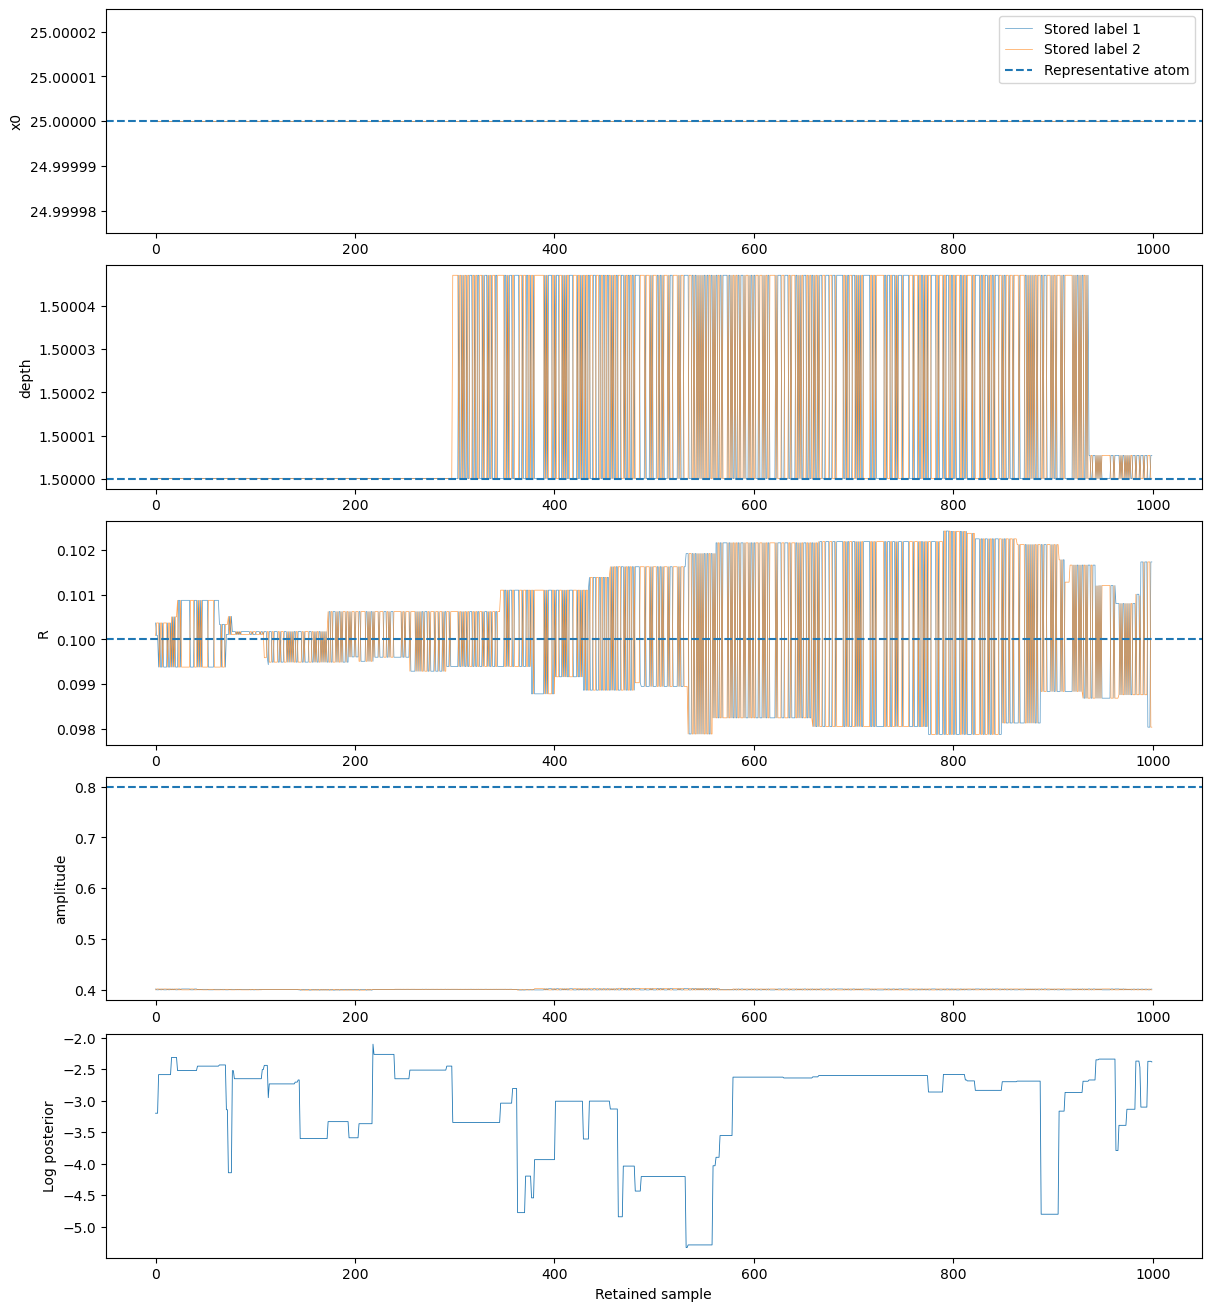

In [30]:
figure, axes = plt.subplots(
    5,
    1,
    figsize=(12, 13),
    constrained_layout=True,
)

for parameter_index, (axis, parameter_name) in enumerate(
    zip(axes[:4], PARAMETER_NAMES)
):
    label_1_values = chain[:, 0, parameter_index]
    label_2_values = chain[:, 1, parameter_index]
    representative_value = representative_vector[parameter_index]

    axis.plot(
        label_1_values,
        linewidth=0.5,
        alpha=0.75,
        label="Stored label 1",
    )
    axis.plot(
        label_2_values,
        linewidth=0.5,
        alpha=0.75,
        label="Stored label 2",
    )

    axis.axhline(
        representative_value,
        linestyle="--",
        linewidth=1.5,
        label="Representative atom",
    )

    # Choose the vertical range from the actual sampled values.
    all_values = np.concatenate(
        [
            label_1_values,
            label_2_values,
            np.array([representative_value]),
        ]
    )

    value_min = np.min(all_values)
    value_max = np.max(all_values)
    value_range = value_max - value_min

    if value_range > 0.0:
        padding = 0.05 * value_range
    else:
        # Handle a trace that is exactly constant.
        padding = max(
            1e-8,
            1e-6 * max(1.0, abs(representative_value)),
        )

    axis.set_ylim(
        value_min - padding,
        value_max + padding,
    )

    # Show full parameter values rather than notation such as
    # "1e-5 + 1.5".
    axis.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

    axis.set_ylabel(parameter_name)

axes[0].legend()

axes[4].plot(
    log_posterior_chain,
    linewidth=0.6,
)
axes[4].set_xlabel("Retained sample")
axes[4].set_ylabel("Log posterior")
axes[4].ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False,
)

plt.show()

### Construct the single-atom marginal sample

In [26]:
# Shape:
# chain          = (number of scenes, 2 atoms, 4 parameters)
# marginal_draws = (2 * number of scenes, 4 parameters)

marginal_draws = chain.reshape(-1, 4)

print("Number of retained two-atom scenes:", chain.shape[0])
print("Number of pooled single-atom draws:", marginal_draws.shape[0])
print("Marginal-draw shape:", marginal_draws.shape)

Number of retained two-atom scenes: 1000
Number of pooled single-atom draws: 2000
Marginal-draw shape: (2000, 4)


### Plot the four one-dimensional marginal densities

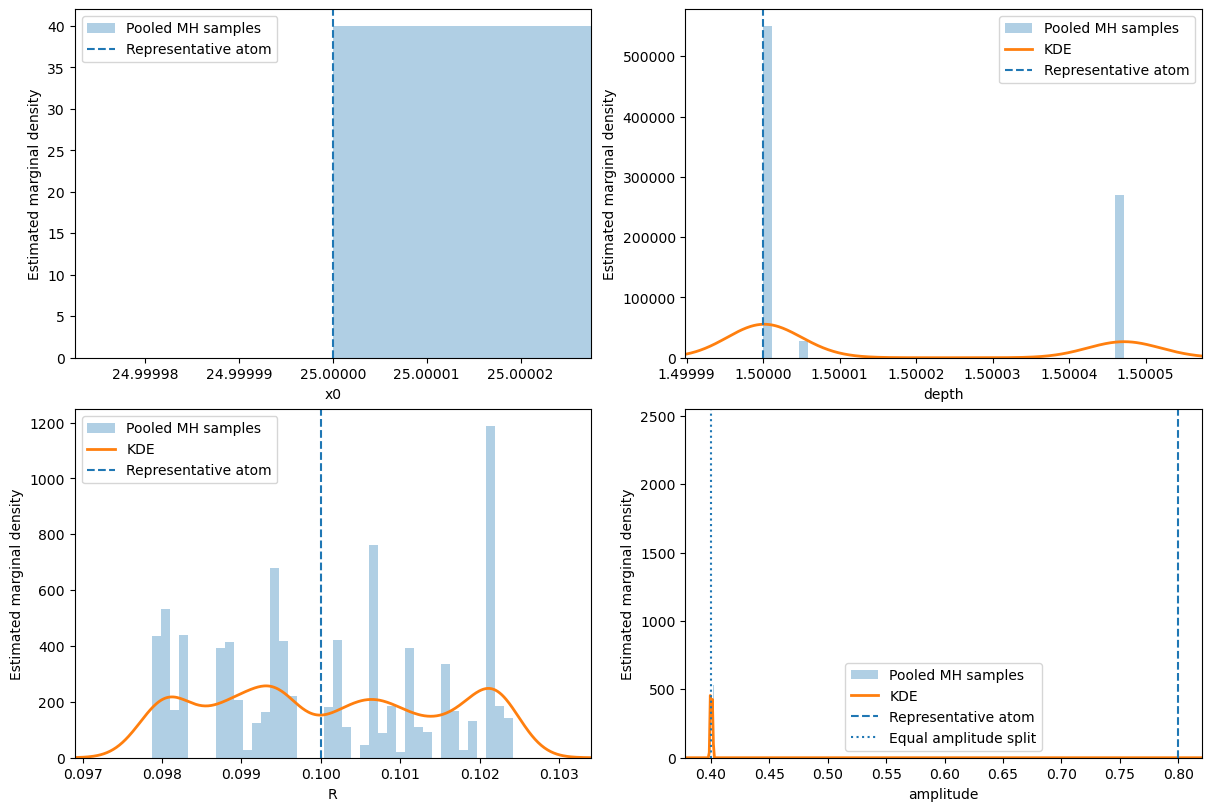

In [38]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

for parameter_index, axis in enumerate(axes.flat):
    values = marginal_draws[:, parameter_index]

    # Use a central plotting window based on the sampled values,
    # rather than the full prior support.
    q_low, q_high = np.quantile(values, [0.001, 0.999])
    x_min = np.min(values)
    x_max = np.max(values)

    span = q_high - q_low
    if span > 0.0:
        padding = 0.15 * span
    else:
        padding = max(1e-8, 1e-6 * max(1.0, abs(np.mean(values))))

    plot_lower = min(x_min, q_low) - padding
    plot_upper = max(x_max, q_high) + padding

    # Keep the plotting window inside the parameter support.
    support_lower, support_upper = support_limits[parameter_index]
    plot_lower = max(plot_lower, support_lower)
    plot_upper = min(plot_upper, support_upper)

    # If the representative value lies outside the sampled central window,
    # expand slightly so it is still visible.
    representative_value = representative_vector[parameter_index]
    plot_lower = min(plot_lower, representative_value)
    plot_upper = max(plot_upper, representative_value)

    if parameter_index == 3:
        equal_split_value = representative_atom.amplitude / 2.0
        plot_lower = min(plot_lower, equal_split_value)
        plot_upper = max(plot_upper, equal_split_value)

    # Add a little extra padding after including reference lines.
    final_span = plot_upper - plot_lower
    if final_span > 0.0:
        extra_padding = 0.05 * final_span
    else:
        extra_padding = max(1e-8, 1e-6 * max(1.0, abs(plot_lower)))

    plot_lower -= extra_padding
    plot_upper += extra_padding

    # Histogram only over the visible region for clarity.
    visible_values = values[
        (values >= plot_lower) & (values <= plot_upper)
    ]

    axis.hist(
        visible_values,
        bins=40,
        density=True,
        alpha=0.35,
        label="Pooled MH samples",
    )

    # Draw a KDE unless the samples have essentially zero variance.
    if np.std(values) > 1e-12:
        kde = gaussian_kde(values)
        grid = np.linspace(plot_lower, plot_upper, 500)

        axis.plot(
            grid,
            kde(grid),
            linewidth=2,
            label="KDE",
        )

    axis.axvline(
        representative_value,
        linestyle="--",
        linewidth=1.5,
        label="Representative atom",
    )

    if parameter_index == 3:
        axis.axvline(
            representative_atom.amplitude / 2.0,
            linestyle=":",
            linewidth=1.5,
            label="Equal amplitude split",
        )

    axis.set_xlim(plot_lower, plot_upper)
    axis.ticklabel_format(
        axis="x",
        style="plain",
        useOffset=False,
    )
    axis.set_xlabel(PARAMETER_NAMES[parameter_index])
    axis.set_ylabel("Estimated marginal density")
    axis.legend()

plt.show()

### Plot posterior slices

In [39]:
def evaluate_1d_slice(
    centre_state,
    atom_index,
    parameter_index,
    grid,
):
    """Evaluate the log posterior along a one-dimensional slice."""
    log_values = np.empty_like(grid, dtype=float)

    for grid_index, value in enumerate(grid):
        state = centre_state.copy()
        state[atom_index, parameter_index] = value
        log_values[grid_index] = log_posterior(state)

    return log_values

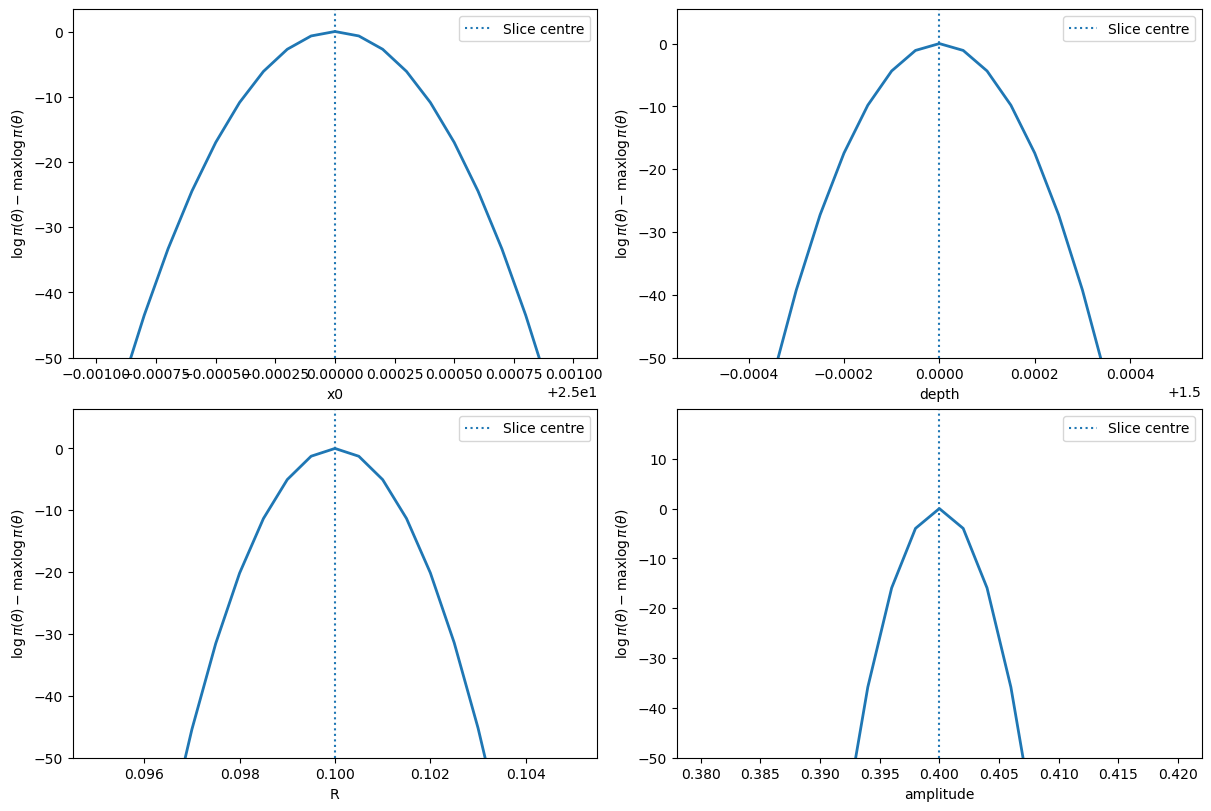

In [47]:
slice_grids = [
    np.linspace(25.0 - 0.001, 25.0 + 0.001, 21),          # x0
    np.linspace(1.5 - 0.0005, 1.5 + 0.0005, 21),        # depth
    np.linspace(0.1 - 0.005, 0.1 + 0.005, 21),            # R
    np.linspace(0.4 - 0.02, 0.4 + 0.02, 21),            # amplitude
]

figure, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

atom_index = 0

for parameter_index, axis in enumerate(axes.flat):
    grid = slice_grids[parameter_index]

    log_values = evaluate_1d_slice(
        initial_state,
        atom_index,
        parameter_index,
        grid,
    )

    relative_log_values = log_values - np.max(log_values)

    axis.plot(
        grid,
        relative_log_values,
        linewidth=2,
    )

    axis.axvline(
        initial_state[atom_index, parameter_index],
        linestyle=":",
        linewidth=1.5,
        label="Slice centre",
    )

    # axis.axvline(
    #     representative_vector[parameter_index],
    #     linestyle="--",
    #     linewidth=1.5,
    #     label="Representative atom value",
    # )

    axis.set_xlabel(PARAMETER_NAMES[parameter_index])
    axis.set_ylabel(
        r"$\log \pi(\theta)-\max \log \pi(\theta)$"
    )
    axis.set_ylim(bottom=-50)
    axis.legend()

plt.show()

### Plot two-dimensional amplitude slice

In [49]:
amplitude_1_grid = np.linspace(0.4 - 0.02, 0.4 + 0.02, 11)
amplitude_2_grid = np.linspace(0.4 - 0.02, 0.4 + 0.02, 11)

amplitude_log_values = np.empty(
    (len(amplitude_2_grid), len(amplitude_1_grid)),
    dtype=float,
)

for row, amplitude_2 in enumerate(amplitude_2_grid):
    for column, amplitude_1 in enumerate(amplitude_1_grid):
        state = initial_state.copy()
        state[0, 3] = amplitude_1
        state[1, 3] = amplitude_2

        amplitude_log_values[row, column] = log_posterior(state)

amplitude_relative_log_values = (
    amplitude_log_values - np.max(amplitude_log_values)
)

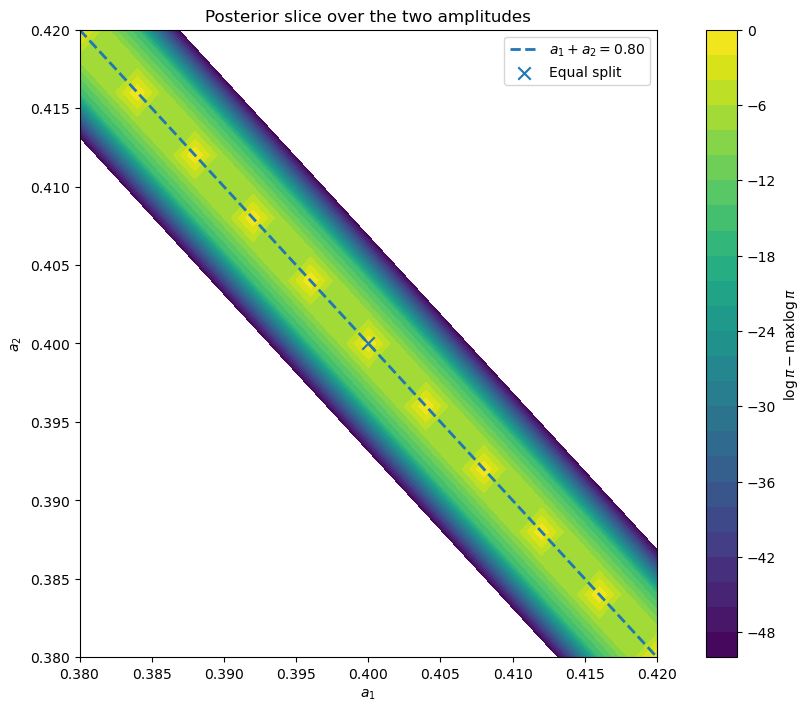

In [50]:
figure, axis = plt.subplots(
    figsize=(8, 7),
    constrained_layout=True,
)

contour = axis.contourf(
    amplitude_1_grid,
    amplitude_2_grid,
    amplitude_relative_log_values,
    levels=np.linspace(-50.0, 0.0, 26),
)

figure.colorbar(
    contour,
    ax=axis,
    label=r"$\log \pi-\max\log\pi$",
)

ridge_grid = np.linspace(0.4 - 0.02, 0.4 + 0.02, 300)

axis.plot(
    ridge_grid,
    representative_atom.amplitude - ridge_grid,
    linestyle="--",
    linewidth=2,
    label=(
        rf"$a_1+a_2="
        rf"{representative_atom.amplitude:.2f}$"
    ),
)

axis.scatter(
    [initial_state[0, 3]],
    [initial_state[1, 3]],
    marker="x",
    s=80,
    label="Equal split",
)

axis.set_xlabel(r"$a_1$")
axis.set_ylabel(r"$a_2$")
axis.set_title("Posterior slice over the two amplitudes")
axis.legend()

plt.show()

### Plot two-dimensional slices

In [52]:
def evaluate_2d_atom_slice(
    centre_state,
    parameter_index,
    grid_1,
    grid_2,
):
    """Evaluate a two-dimensional posterior slice.

    The selected parameter is varied independently for atoms 1 and 2.
    All other parameters remain fixed at centre_state.

    Returns
    -------
    log_values : ndarray
        Array with shape (len(grid_2), len(grid_1)). Rows correspond
        to atom 2 values and columns correspond to atom 1 values.
    """
    log_values = np.empty(
        (len(grid_2), len(grid_1)),
        dtype=float,
    )

    for row, value_2 in enumerate(grid_2):
        for column, value_1 in enumerate(grid_1):
            state = centre_state.copy()

            state[0, parameter_index] = value_1
            state[1, parameter_index] = value_2

            log_values[row, column] = log_posterior(state)

    return log_values

In [71]:
slice_grids = [
    np.linspace(25.0 - 0.001, 25.0 + 0.001, 11),       # x0
    np.linspace(1.5 - 0.0003, 1.5 + 0.0003, 11),     # depth
    np.linspace(0.1 - 0.003, 0.1 + 0.003, 11),         # R
    np.linspace(0.4 - 0.005, 0.4 + 0.005, 11),             # amplitude
]

In [72]:
slice_log_values = []

for parameter_index, grid in enumerate(slice_grids):
    print(f"Evaluating {PARAMETER_NAMES[parameter_index]} slice...")

    log_values = evaluate_2d_atom_slice(
        initial_state,
        parameter_index,
        grid,
        grid,
    )

    # Express values relative to the maximum on this slice.
    finite_mask = np.isfinite(log_values)

    relative_log_values = np.full_like(
        log_values,
        -np.inf,
    )

    relative_log_values[finite_mask] = (
        log_values[finite_mask]
        - np.max(log_values[finite_mask])
    )

    slice_log_values.append(relative_log_values)

Evaluating x0 slice...
Evaluating depth slice...
Evaluating R slice...
Evaluating amplitude slice...


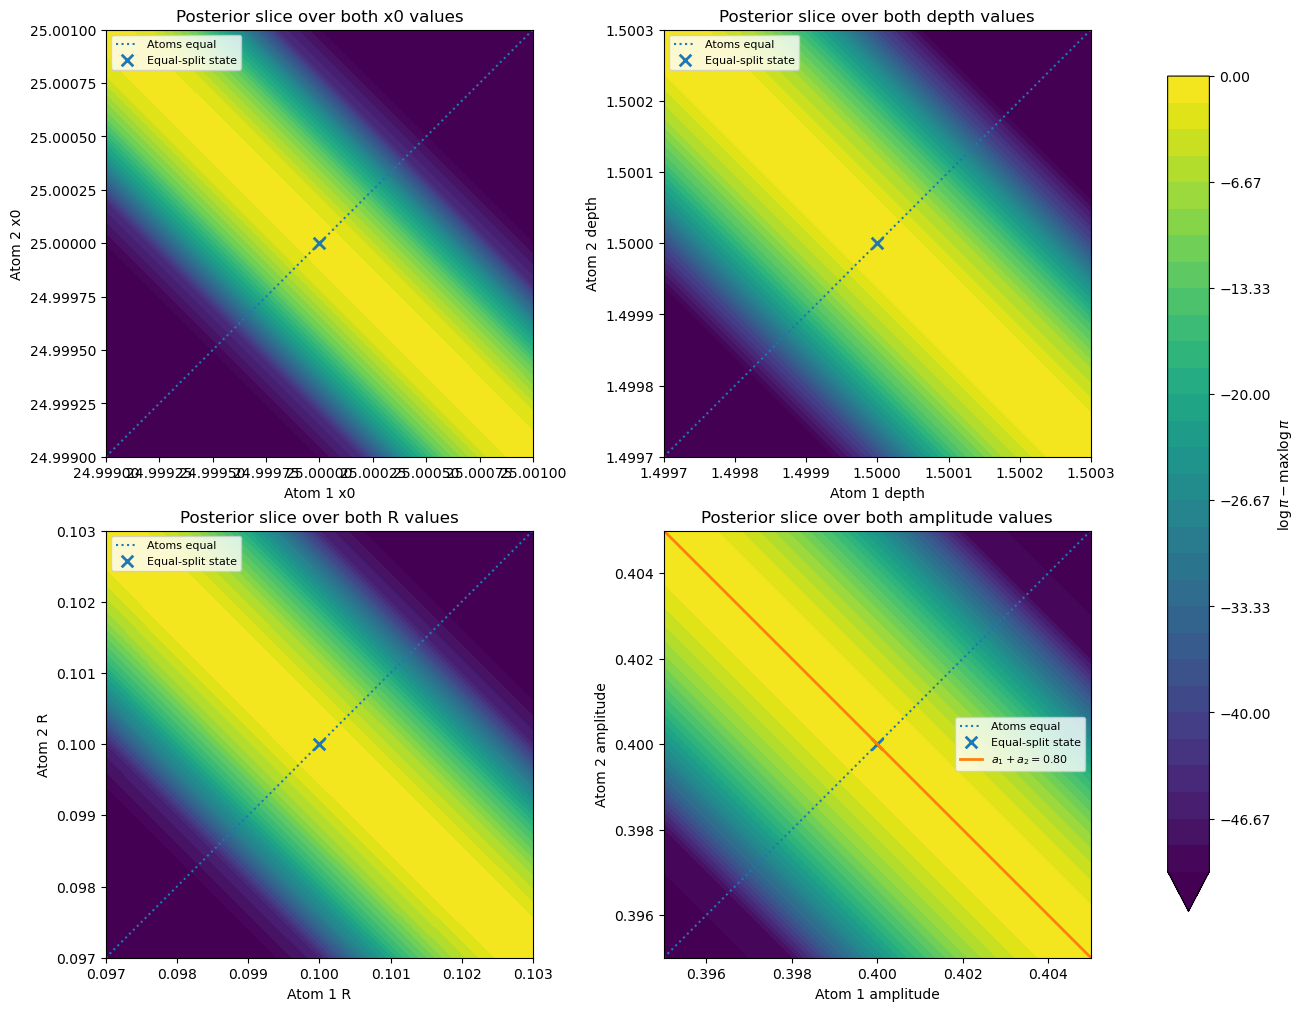

In [73]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10),
    constrained_layout=True,
)

# Only display the region within 50 log-posterior units of the
# best point on each slice.
display_minimum = -50.0
levels = np.linspace(display_minimum, 0.0, 31)

for parameter_index, axis in enumerate(axes.flat):
    grid = slice_grids[parameter_index]
    relative_log_values = slice_log_values[parameter_index]

    # Clip very small values so that the high-posterior structure
    # remains visually clear.
    displayed_values = np.clip(
        relative_log_values,
        display_minimum,
        0.0,
    )

    heatmap = axis.contourf(
        grid,
        grid,
        displayed_values,
        levels=levels,
        extend="min",
    )

    # Line where both atoms have the same parameter value.
    axis.plot(
        grid,
        grid,
        linestyle=":",
        linewidth=1.5,
        label="Atoms equal",
    )

    # Equal-split state around which the slice is taken.
    centre_value = initial_state[0, parameter_index]

    axis.scatter(
        [centre_value],
        [centre_value],
        marker="x",
        s=70,
        linewidth=2,
        label="Equal-split state",
    )

    # Representative single-atom value.
    representative_value = representative_vector[parameter_index]

    # axis.axvline(
    #     representative_value,
    #     linestyle="--",
    #     linewidth=1.2,
    # )
    # axis.axhline(
    #     representative_value,
    #     linestyle="--",
    #     linewidth=1.2,
    #     label="Representative value",
    # )

    # For amplitude, show the exact amplitude-sum ridge.
    if parameter_index == 3:
        valid_ridge = (
            representative_atom.amplitude - grid >= grid[0]
        ) & (
            representative_atom.amplitude - grid <= grid[-1]
        )

        axis.plot(
            grid[valid_ridge],
            representative_atom.amplitude - grid[valid_ridge],
            linewidth=2,
            label=(
                rf"$a_1+a_2="
                rf"{representative_atom.amplitude:.2f}$"
            ),
        )

    parameter_name = PARAMETER_NAMES[parameter_index]

    axis.set_xlabel(f"Atom 1 {parameter_name}")
    axis.set_ylabel(f"Atom 2 {parameter_name}")
    axis.set_title(f"Posterior slice over both {parameter_name} values")
    axis.set_aspect("equal", adjustable="box")
    axis.ticklabel_format(
        axis="both",
        style="plain",
        useOffset=False,
    )
    axis.legend(fontsize=8)

colorbar = figure.colorbar(
    heatmap,
    ax=axes,
    shrink=0.9,
    label=r"$\log \pi-\max \log \pi$",
)

plt.show()

### Produce marginal over one atom with quadrature

In [74]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.polynomial.legendre import leggauss
from scipy.special import ndtr, log_ndtr

In [78]:
# ============================================================
# USER INPUTS
# ============================================================

# The single representative atom that generates the
# noise-free synthetic observed data.
representative_atom = Atom(
    x0=25.0,
    depth=1.5,
    R=0.1,
    amplitude=0.8,
    eps_r=1.0
)

# Observation-noise standard deviation used in the posterior.
sigma = 0.02

# Radius prior:
#
#     R ~ Exponential(lambda_R)
#
lambda_R = 10.0

# Full prior support for horizontal position and depth.
#
# These must agree with the values used in your model.
X_MAX = 50.0
D_MAX = 5.0


# ------------------------------------------------------------
# Region over which the SECOND atom is integrated out.
# ------------------------------------------------------------
#
# The amplitude is integrated analytically.
# The other three parameters are integrated using quadrature.
#
# These are EXAMPLE local ranges. Replace them with the ranges
# you want to investigate.

second_atom_bounds = {
    "x0": (25.0 - 0.002, 25.0 + 0.002),
    "depth": (1.5 - 0.0001, 1.5 + 0.0001),
    "R": (0.09, 0.11),
    "amplitude": (-1.0, 1.0),
}


# Number of Gauss-Legendre nodes in each integrated dimension.
#
# The total number of second-atom geometries is
#
#     n_x0 * n_depth * n_R.
#
# Start with 5 in each dimension, giving 5^3 = 125 points.
quadrature_order = {
    "x0": 5,
    "depth": 5,
    "R": 5,
}


# ------------------------------------------------------------
# Grid over which the FIRST-atom marginal is evaluated.
# ------------------------------------------------------------
#
# The output will have shape
#
#   (
#       len(x0),
#       len(depth),
#       len(R),
#       len(amplitude),
#   ).
#
# The code evaluates all first-atom amplitudes together for
# each first-atom geometry, which is much faster than rendering
# the same geometry once for every amplitude.

first_atom_grid = {
    "x0": np.linspace(
        25.0 - 0.0002,
        25.0 + 0.0002,
        5,
    ),
    "depth": np.linspace(
        1.5 - 0.0001,
        1.5 + 0.0001,
        5,
    ),
    "R": np.linspace(
        0.1 - 0.002,
        0.1 + 0.002,
        5,
    ),
    "amplitude": np.linspace(
        -1.0,
        1.0,
        81,
    ),
}


# ------------------------------------------------------------
# Optional response caching
# ------------------------------------------------------------
#
# False is memory-safe but re-renders second-atom responses
# for each first-atom geometry.
#
# True can be substantially faster, but can require a very
# large amount of memory because an entire Nt x Nx response
# is stored for every quadrature point.
#
# Leave this False initially.
CACHE_SECOND_RESPONSES = False

# Only used when CACHE_SECOND_RESPONSES is True.
CACHE_DTYPE = np.float32

In [81]:
# ============================================================
# SYNTHETIC OBSERVED DATA
# ============================================================

wavelet = scene.wavelet
soil = scene.soil
grid = scene.grid

synthetic_data = render_atom(
    representative_atom,
    grid,
    wavelet,
    soil,
)

y0 = np.asarray(
    synthetic_data,
    dtype=np.float64,
).ravel()

y0_norm_squared = float(np.dot(y0, y0))

print("Synthetic data shape:", synthetic_data.shape)
print("Number of data values:", y0.size)
print("Squared data norm:", y0_norm_squared)

Synthetic data shape: (2000, 5000)
Number of data values: 10000000
Squared data norm: 509.6803637097993


In [94]:
# ============================================================
# BASIC HELPERS
# ============================================================

def make_atom(
    x0: float,
    depth: float,
    R: float,
    amplitude: float,
) -> Atom:
    """Construct an Atom using scalar floating-point values."""
    return Atom(
        x0=float(x0),
        depth=float(depth),
        R=float(R),
        amplitude=float(amplitude),
        eps_r=1.0
    )


def render_unit_response(
    x0: float,
    depth: float,
    R: float,
) -> np.ndarray:
    """Render the flattened response for a unit-amplitude atom."""
    atom = make_atom(
        x0=x0,
        depth=depth,
        R=R,
        amplitude=1.0,
    )

    response = render_atom(
        atom,
        grid,
        wavelet,
        soil,
    )

    return np.asarray(
        response,
        dtype=np.float64,
    ).ravel()


def gauss_legendre_interval(
    lower: float,
    upper: float,
    order: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Gauss-Legendre nodes and weights on [lower, upper]."""
    if upper <= lower:
        raise ValueError(
            f"Invalid interval [{lower}, {upper}]."
        )

    if order < 1:
        raise ValueError("Quadrature order must be positive.")

    standard_nodes, standard_weights = leggauss(order)

    midpoint = 0.5 * (lower + upper)
    half_width = 0.5 * (upper - lower)

    nodes = midpoint + half_width * standard_nodes
    weights = half_width * standard_weights

    return nodes, weights

In [83]:
# ============================================================
# NUMERICALLY STABLE NORMAL-CDF INTERVAL
# ============================================================

def _log_subtract_exp(
    log_larger: np.ndarray,
    log_smaller: np.ndarray,
) -> np.ndarray:
    """Return log(exp(log_larger) - exp(log_smaller)).

    Assumes log_larger >= log_smaller.
    """
    difference = log_smaller - log_larger
    difference = np.minimum(difference, 0.0)

    with np.errstate(divide="ignore", invalid="ignore"):
        return log_larger + np.log(
            -np.expm1(difference)
        )


def log_normal_cdf_interval(
    z_lower: np.ndarray,
    z_upper: np.ndarray,
) -> np.ndarray:
    """Compute log(Phi(z_upper) - Phi(z_lower)) stably."""
    z_lower, z_upper = np.broadcast_arrays(
        np.asarray(z_lower, dtype=float),
        np.asarray(z_upper, dtype=float),
    )

    if np.any(z_upper < z_lower):
        raise ValueError(
            "Every upper normal limit must be at least its "
            "corresponding lower limit."
        )

    result = np.empty_like(z_lower)

    # Both bounds are in the lower tail.
    lower_tail = z_upper <= 0.0

    if np.any(lower_tail):
        log_upper = log_ndtr(z_upper[lower_tail])
        log_lower = log_ndtr(z_lower[lower_tail])

        result[lower_tail] = _log_subtract_exp(
            log_upper,
            log_lower,
        )

    # Both bounds are in the upper tail.
    #
    # Phi(u) - Phi(l)
    #     = Phi(-l) - Phi(-u).
    upper_tail = z_lower >= 0.0

    if np.any(upper_tail):
        log_larger = log_ndtr(-z_lower[upper_tail])
        log_smaller = log_ndtr(-z_upper[upper_tail])

        result[upper_tail] = _log_subtract_exp(
            log_larger,
            log_smaller,
        )

    # The interval crosses zero. Direct subtraction is stable.
    central = ~(lower_tail | upper_tail)

    if np.any(central):
        probability = (
            ndtr(z_upper[central])
            -
            ndtr(z_lower[central])
        )

        result[central] = np.log(probability)

    return result

In [85]:
# ============================================================
# SECOND-ATOM GEOMETRY QUADRATURE
# ============================================================

def validate_second_atom_bounds() -> None:
    x_lower, x_upper = second_atom_bounds["x0"]
    d_lower, d_upper = second_atom_bounds["depth"]
    R_lower, R_upper = second_atom_bounds["R"]
    a_lower, a_upper = second_atom_bounds["amplitude"]

    if x_lower < 0.0 or x_upper > X_MAX:
        raise ValueError(
            "Second-atom x0 bounds must lie within [0, X_MAX]."
        )

    if d_lower < 0.0 or d_upper > D_MAX:
        raise ValueError(
            "Second-atom depth bounds must lie within "
            "[0, D_MAX]."
        )

    if R_lower < 0.0:
        raise ValueError(
            "Second-atom radius lower bound must be nonnegative."
        )

    if a_lower < -1.0 or a_upper > 1.0:
        raise ValueError(
            "Second-atom amplitude bounds must lie within "
            "[-1, 1]."
        )

    if a_upper <= a_lower:
        raise ValueError(
            "Second-atom amplitude interval must have "
            "positive width."
        )


def build_second_atom_quadrature() -> list[tuple[float, float, float, float]]:
    """Build quadrature points for x2, d2 and R2.

    Each result is

        (x2, d2, R2, log_weight_and_geometry_prior).
    """
    validate_second_atom_bounds()

    x_nodes, x_weights = gauss_legendre_interval(
        *second_atom_bounds["x0"],
        quadrature_order["x0"],
    )

    d_nodes, d_weights = gauss_legendre_interval(
        *second_atom_bounds["depth"],
        quadrature_order["depth"],
    )

    R_nodes, R_weights = gauss_legendre_interval(
        *second_atom_bounds["R"],
        quadrature_order["R"],
    )

    points = []

    # Geometry prior:
    #
    # p(x, d, R)
    #   = (1 / X_MAX)
    #     (1 / D_MAX)
    #     lambda_R exp(-lambda_R R).
    log_uniform_geometry_constant = (
        -np.log(X_MAX)
        -np.log(D_MAX)
    )

    for x_index, x2 in enumerate(x_nodes):
        for d_index, d2 in enumerate(d_nodes):
            for R_index, R2 in enumerate(R_nodes):
                quadrature_weight = (
                    x_weights[x_index]
                    * d_weights[d_index]
                    * R_weights[R_index]
                )

                log_radius_prior = (
                    np.log(lambda_R)
                    -lambda_R * R2
                )

                log_weight_and_prior = (
                    np.log(quadrature_weight)
                    +log_uniform_geometry_constant
                    +log_radius_prior
                )

                points.append(
                    (
                        float(x2),
                        float(d2),
                        float(R2),
                        float(log_weight_and_prior),
                    )
                )

    return points


second_quadrature_points = build_second_atom_quadrature()

print(
    "Number of second-atom geometry quadrature points:",
    len(second_quadrature_points),
)

Number of second-atom geometry quadrature points: 125


In [86]:
# ============================================================
# ANALYTICAL INTEGRATION OVER a2
# ============================================================

A2_LOWER, A2_UPPER = second_atom_bounds["amplitude"]

# Under the original prior,
#
#     a2 ~ Uniform(-1, 1),
#
# so its density is 1/2 even when we integrate over only a
# smaller local subinterval.
LOG_AMPLITUDE_PRIOR_DENSITY = -np.log(2.0)


def log_integrated_second_amplitude(
    residual_norm_squared: np.ndarray,
    projection: np.ndarray,
    phi2_norm_squared: float,
) -> np.ndarray:
    """Log of the likelihood integrated over second amplitude.

    Parameters
    ----------
    residual_norm_squared
        ||y0 - a1 phi1||^2 for every first amplitude a1.

    projection
        <phi2, y0 - a1 phi1> for every first amplitude a1.

    phi2_norm_squared
        ||phi2||^2.

    Returns
    -------
    Array with one log integral for every first amplitude.
    """
    if phi2_norm_squared <= 0.0:
        raise ValueError(
            "The second-atom unit response has zero norm."
        )

    response_norm = np.sqrt(phi2_norm_squared)

    conditional_mean = (
        projection
        / phi2_norm_squared
    )

    conditional_sd = (
        sigma
        / response_norm
    )

    z_lower = (
        A2_LOWER - conditional_mean
    ) / conditional_sd

    z_upper = (
        A2_UPPER - conditional_mean
    ) / conditional_sd

    log_probability_interval = log_normal_cdf_interval(
        z_lower,
        z_upper,
    )

    # Orthogonal residual:
    #
    # ||r||^2 - <phi2, r>^2 / ||phi2||^2.
    orthogonal_residual_squared = (
        residual_norm_squared
        -
        projection**2 / phi2_norm_squared
    )

    # Remove very small negative values caused by rounding.
    orthogonal_residual_squared = np.maximum(
        orthogonal_residual_squared,
        0.0,
    )

    log_integral = (
        -orthogonal_residual_squared
        / (2.0 * sigma**2)
        +0.5 * np.log(2.0 * np.pi)
        +np.log(conditional_sd)
        +log_probability_interval
    )

    # Include the Uniform(-1, 1) prior density for a2.
    return (
        log_integral
        +LOG_AMPLITUDE_PRIOR_DENSITY
    )

In [89]:
# ============================================================
# OPTIONAL SECOND-RESPONSE CACHE
# ============================================================

def build_second_response_cache():
    """Pre-render unit responses for all quadrature geometries."""
    bytes_per_response = (
        y0.size
        * np.dtype(CACHE_DTYPE).itemsize
    )

    estimated_gigabytes = (
        bytes_per_response
        * len(second_quadrature_points)
        / 1.0e9
    )

    print(
        "Estimated response-cache size:",
        f"{estimated_gigabytes:.3f} GB",
    )

    cache = []

    for point_index, (
        x2,
        d2,
        R2,
        log_weight_and_prior,
    ) in enumerate(second_quadrature_points):
        phi2 = render_unit_response(
            x0=x2,
            depth=d2,
            R=R2,
        ).astype(
            CACHE_DTYPE,
            copy=False,
        )

        phi2_norm_squared = float(
            np.sum(
                phi2 * phi2,
                dtype=np.float64,
            )
        )

        phi2_dot_y0 = float(
            np.sum(
                phi2 * y0,
                dtype=np.float64,
            )
        )

        cache.append(
            (
                phi2,
                phi2_norm_squared,
                phi2_dot_y0,
                log_weight_and_prior,
            )
        )

        if (
            point_index == 0
            or (point_index + 1) % 50 == 0
            or point_index + 1 == len(second_quadrature_points)
        ):
            print(
                "Cached",
                point_index + 1,
                "of",
                len(second_quadrature_points),
            )

    return cache


if CACHE_SECOND_RESPONSES:
    second_response_cache = build_second_response_cache()
else:
    second_response_cache = None

In [90]:
# ============================================================
# MARGINAL FOR FIXED FIRST-ATOM GEOMETRY
# ============================================================

def log_one_atom_marginal_for_geometry(
    x1: float,
    d1: float,
    R1: float,
    amplitude_values: np.ndarray,
) -> np.ndarray:
    """Evaluate the one-atom log marginal for fixed x1,d1,R1.

    The calculation is vectorised over amplitude_values.
    """
    amplitude_values = np.asarray(
        amplitude_values,
        dtype=float,
    )

    # Check first-atom geometric support.
    if not (0.0 <= x1 <= X_MAX):
        return np.full_like(
            amplitude_values,
            -np.inf,
        )

    if not (0.0 <= d1 <= D_MAX):
        return np.full_like(
            amplitude_values,
            -np.inf,
        )

    if R1 < 0.0:
        return np.full_like(
            amplitude_values,
            -np.inf,
        )

    phi1 = render_unit_response(
        x0=x1,
        depth=d1,
        R=R1,
    )

    phi1_norm_squared = float(
        np.dot(phi1, phi1)
    )

    phi1_dot_y0 = float(
        np.dot(phi1, y0)
    )

    # For each a1:
    #
    # ||y0 - a1 phi1||^2
    #   = ||y0||^2
    #     - 2 a1 <phi1,y0>
    #     + a1^2 ||phi1||^2.
    residual_norm_squared = (
        y0_norm_squared
        -2.0 * amplitude_values * phi1_dot_y0
        +amplitude_values**2 * phi1_norm_squared
    )

    residual_norm_squared = np.maximum(
        residual_norm_squared,
        0.0,
    )

    log_integral = np.full_like(
        amplitude_values,
        -np.inf,
    )

    if second_response_cache is not None:
        # Fast path: use cached second-atom responses.
        for (
            phi2,
            phi2_norm_squared,
            phi2_dot_y0,
            log_weight_and_prior,
        ) in second_response_cache:
            phi2_dot_phi1 = float(
                np.sum(
                    phi2 * phi1,
                    dtype=np.float64,
                )
            )

            # <phi2, y0 - a1 phi1>
            projection = (
                phi2_dot_y0
                -amplitude_values * phi2_dot_phi1
            )

            log_amplitude_integral = (
                log_integrated_second_amplitude(
                    residual_norm_squared=
                        residual_norm_squared,
                    projection=projection,
                    phi2_norm_squared=
                        phi2_norm_squared,
                )
            )

            log_integral = np.logaddexp(
                log_integral,
                log_weight_and_prior
                +log_amplitude_integral,
            )

    else:
        # Memory-safe path: render one second response at a time.
        for (
            x2,
            d2,
            R2,
            log_weight_and_prior,
        ) in second_quadrature_points:
            phi2 = render_unit_response(
                x0=x2,
                depth=d2,
                R=R2,
            )

            phi2_norm_squared = float(
                np.dot(phi2, phi2)
            )

            phi2_dot_y0 = float(
                np.dot(phi2, y0)
            )

            phi2_dot_phi1 = float(
                np.dot(phi2, phi1)
            )

            projection = (
                phi2_dot_y0
                -amplitude_values * phi2_dot_phi1
            )

            log_amplitude_integral = (
                log_integrated_second_amplitude(
                    residual_norm_squared=
                        residual_norm_squared,
                    projection=projection,
                    phi2_norm_squared=
                        phi2_norm_squared,
                )
            )

            log_integral = np.logaddexp(
                log_integral,
                log_weight_and_prior
                +log_amplitude_integral,
            )

    # First-atom prior:
    #
    # p(x1,d1,R1,a1)
    #   = 1/(X_MAX D_MAX)
    #     lambda_R exp(-lambda_R R1)
    #     1/2.
    log_first_atom_prior = (
        -np.log(X_MAX)
        -np.log(D_MAX)
        +np.log(lambda_R)
        -lambda_R * R1
        -np.log(2.0)
    )

    result = (
        log_first_atom_prior
        +log_integral
    )

    # Enforce the amplitude support.
    valid_amplitude = (
        (amplitude_values >= -1.0)
        &
        (amplitude_values <= 1.0)
    )

    result = np.where(
        valid_amplitude,
        result,
        -np.inf,
    )

    return result

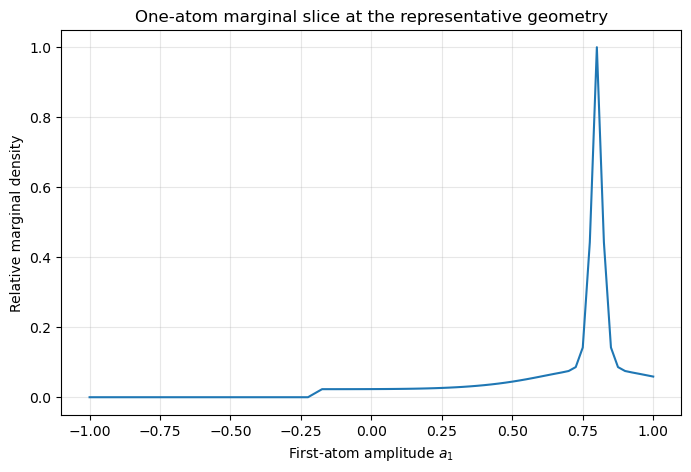

In [95]:
# ============================================================
# QUICK TEST: AMPLITUDE MARGINAL SLICE
# ============================================================

test_amplitudes = first_atom_grid["amplitude"]

test_log_values = log_one_atom_marginal_for_geometry(
    x1=representative_atom.x0,
    d1=representative_atom.depth,
    R1=representative_atom.R,
    amplitude_values=test_amplitudes,
)

test_relative_density = np.exp(
    test_log_values
    -np.max(test_log_values)
)

figure, axis = plt.subplots(
    figsize=(8, 5),
)

axis.plot(
    test_amplitudes,
    test_relative_density,
)

axis.set_xlabel("First-atom amplitude $a_1$")
axis.set_ylabel("Relative marginal density")
axis.set_title(
    "One-atom marginal slice at the representative geometry"
)

axis.grid(alpha=0.3)

plt.show()